In [1]:
import openassetpricing as oap
from tqdm import tqdm
import pandas as pd
import numpy as np

In [2]:
openap = oap.OpenAP()

In [3]:
signal_doc = openap.dl_signal_doc('pandas')

In [4]:
all_features = signal_doc.Acronym.tolist()

In [5]:
import wrds

db = wrds.Connection(wrds_username='francoisgoybet')

query = f"""
select
    permno,
    date,
    ret,
    prc,
    shrout,
    abs(prc*shrout)/1e6 as market_cap_musd
from crsp.msf
where abs(prc*shrout)/1e6 > 100
and date >= '1990-01-01'
order by permno, date
"""

crsp_df = db.raw_sql(query)
crsp_df['date'] = pd.to_datetime(crsp_df['date'])

crsp_df['yyyymm'] = crsp_df['date'].dt.strftime('%Y%m')
crsp_df = crsp_df[['permno', 'yyyymm', 'ret']]

crsp_df['yyyymm'] = crsp_df['yyyymm'].astype(str)  # ensure string for merge
crsp_df = crsp_df.sort_values(['permno', 'yyyymm'])

crsp_df['ret_1m'] = crsp_df.groupby('permno')['ret'].shift(-1)
crsp_df['ret_3m'] = crsp_df.groupby('permno')['ret'].shift(-3)
crsp_df['ret_6m'] = crsp_df.groupby('permno')['ret'].shift(-6)

OperationalError: (psycopg2.OperationalError) connection to server at "wrds-pgdata.wharton.upenn.edu" (165.123.60.118), port 9737 failed: FATAL:  too many connections for role "francoisgoybet"

(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [ ]:
import pandas as pd
from tqdm import tqdm
import openassetpricing as oap

# -----------------------------
# INIT
# -----------------------------
openap = oap.OpenAP()

base = crsp_df.copy()
base['permno'] = base['permno'].astype(int)
base['yyyymm'] = base['yyyymm'].astype(int)

signals = signal_doc.Acronym.tolist()

chunk_size = 20

output_prefix = "ml_dataset_part_"

# -----------------------------
# FUNCTION
# -----------------------------
def load_features(batch_signals):
    df = openap.dl_signal('pandas', batch_signals)

    df['permno'] = df['permno'].astype(int)
    df['yyyymm'] = df['yyyymm'].astype(int)

    return df

# -----------------------------
# MAIN LOOP (MULTI FILE OUTPUT)
# -----------------------------
for i in tqdm(range(0, len(signals), chunk_size), desc="OSAP batching"):
    if i < 120:
        continue
    print(f"Processing signals {i} to {min(i+chunk_size, len(signals))}...")
    batch = signals[i:i+chunk_size]

    feat = load_features(batch)

    # SAFE LEFT MERGE
    base_chunk = base.merge(
        feat,
        on=['permno', 'yyyymm'],
        how='left'
    )

    # -----------------------------
    # 💾 SAVE EACH CHUNK SEPARATELY
    # -----------------------------
    base_chunk.to_parquet(
        f"{output_prefix}{i:04d}.parquet",
        index=False
    )

    del feat, base_chunk

print("DONE — all chunks saved")

OSAP batching:   0%|          | 0/17 [00:00<?, ?it/s]

Processing signals 100 to 120...
One or more input predictors are not available.

Data is downloaded: 15s


OSAP batching:  35%|███▌      | 6/17 [00:15<00:28,  2.59s/it]

Processing signals 120 to 140...


In [9]:
df = pd.read_parquet("ml_dataset_part_0020.parquet")

In [12]:
import pandas as pd
import glob

files = glob.glob("ml_dataset_part_*.parquet")

dfs = [pd.read_parquet(f) for f in files]
# merge them on permno	yyyymm	ret	ret_1m	ret_3m	ret_6m
# we can use reduce to merge them iteratively
from functools import reduce
from functools import reduce
def merge_dfs(left, right):
    return pd.merge(left, right, on=['permno', 'yyyymm', 'ret', 'ret_1m', 'ret_3m', 'ret_6m'], how='outer')
final_df = reduce(merge_dfs, dfs).drop_duplicates(subset=['permno', 'yyyymm']) 

In [22]:
# check the percenage of missing values in each column
missing_percentage = final_df.isnull().mean() * 100
print(missing_percentage.sort_values(ascending=False))
# check number and proportiion of columns with more than x% missing values
threshold = 20
num_cols_above_threshold = (missing_percentage > threshold).sum()
total_cols = len(missing_percentage)
proportion_above_threshold = num_cols_above_threshold / total_cols * 100
print(f"Number of columns with more than {threshold}% missing values: {num_cols_above_threshold}")
print(f"Proportion of columns with more than {threshold}% missing values: {proportion_above_threshold:.2f}%")

ChNAnalyst     100.000000
CitationsRD    100.000000
IndRetBig      100.000000
EarnSupBig     100.000000
Activism1       99.874390
                  ...    
betaVIX          0.014778
IdioVol3F        0.014778
MaxRet           0.007389
permno           0.000000
yyyymm           0.000000
Length: 108, dtype: float64
Number of columns with more than 20% missing values: 30
Proportion of columns with more than 20% missing values: 27.78%


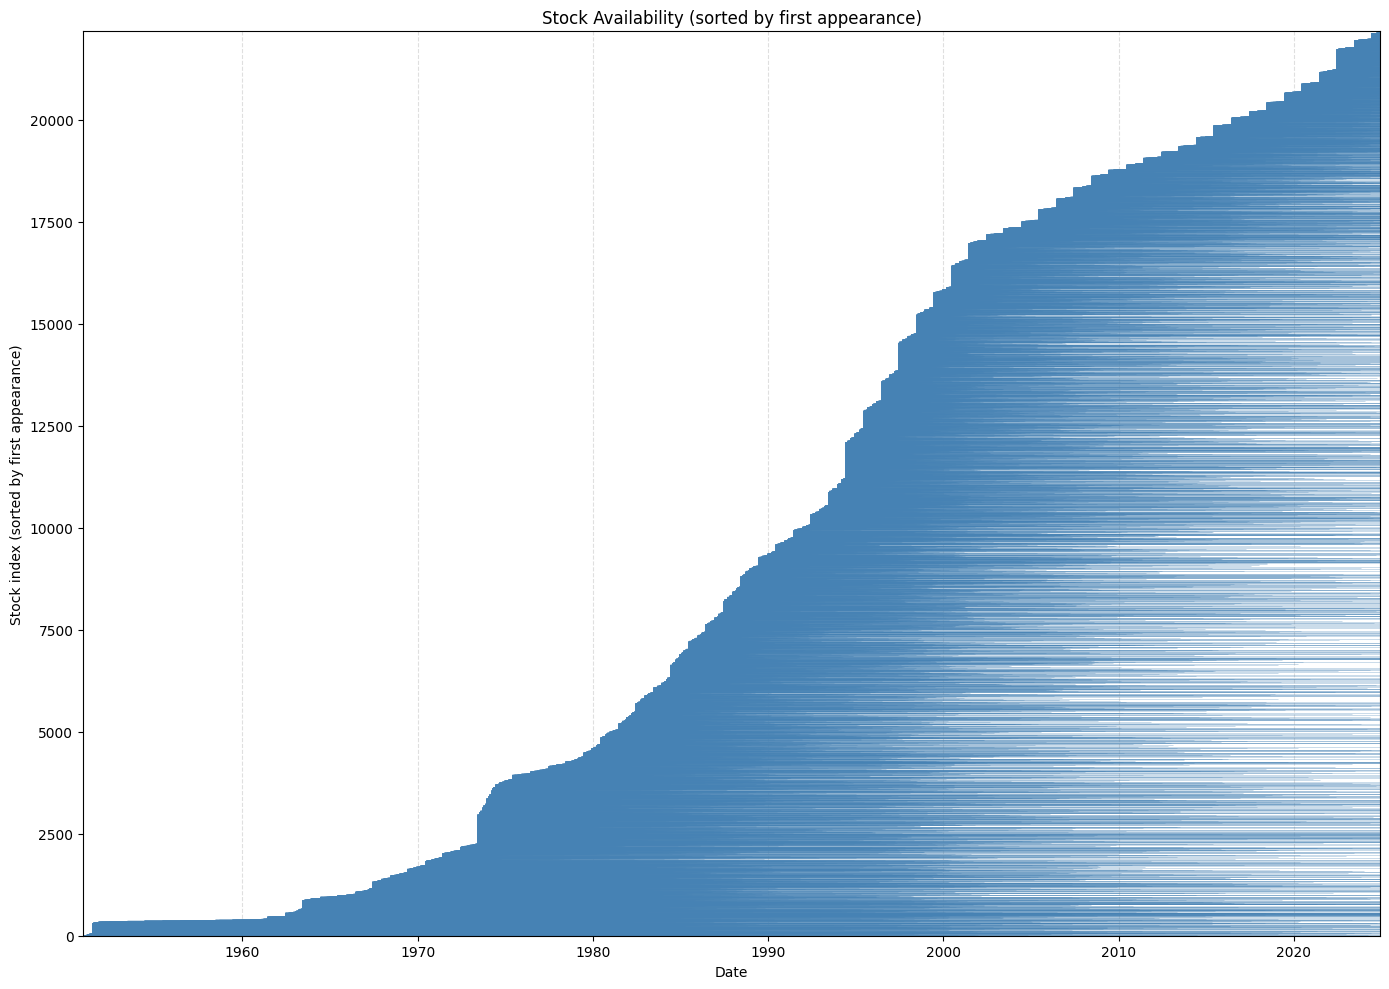

In [14]:

import matplotlib.pyplot as plt
import matplotlib.collections as mc
import matplotlib.dates as mdates
import pandas as pd

# For each stock, find first and last date with non-null BM
stock_dates = (
    df.dropna(subset=['BM'])
    .groupby('permno')['yyyymm']
    .agg(['min', 'max'])
    .reset_index()
)
stock_dates.columns = ['permno', 'first_yyyymm', 'last_yyyymm']

# Convert to datetime
stock_dates['first_date'] = pd.to_datetime(stock_dates['first_yyyymm'].astype(str), format='%Y%m')
stock_dates['last_date']  = pd.to_datetime(stock_dates['last_yyyymm'].astype(str),  format='%Y%m')

# Sort by first appearance
stock_dates = stock_dates.sort_values('first_date').reset_index(drop=True)

# Build a LineCollection for efficiency (one horizontal segment per stock)
segments = [
    [(mdates.date2num(row.first_date), i), (mdates.date2num(row.last_date), i)]
    for i, row in stock_dates.iterrows()
]

lc = mc.LineCollection(segments, linewidths=0.4, alpha=0.5, color='steelblue')

fig, ax = plt.subplots(figsize=(14, 10))
ax.add_collection(lc)
ax.set_xlim(mdates.date2num(stock_dates['first_date'].min()),
            mdates.date2num(stock_dates['last_date'].max()))
ax.set_ylim(-1, len(stock_dates))
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Stock Availability (sorted by first appearance)')
ax.set_xlabel('Date')
ax.set_ylabel('Stock index (sorted by first appearance)')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


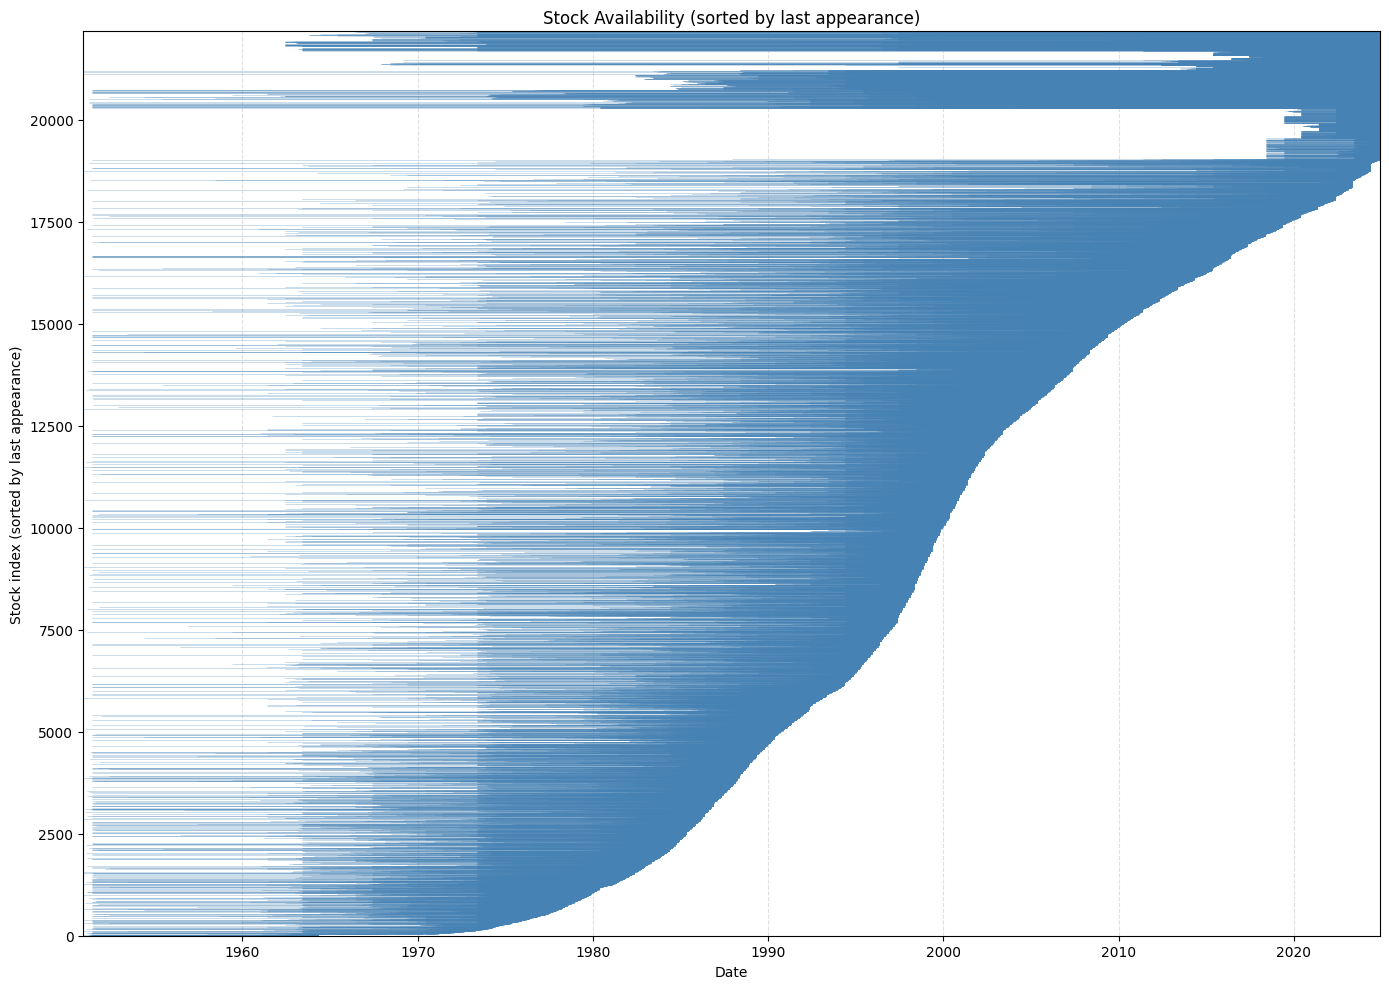

In [15]:

# Sort by last appearance
stock_dates_last = stock_dates.sort_values('last_date').reset_index(drop=True)

segments_last = [
    [(mdates.date2num(row.first_date), i), (mdates.date2num(row.last_date), i)]
    for i, row in stock_dates_last.iterrows()
]

lc_last = mc.LineCollection(segments_last, linewidths=0.4, alpha=0.5, color='steelblue')

fig, ax = plt.subplots(figsize=(14, 10))
ax.add_collection(lc_last)
ax.set_xlim(mdates.date2num(stock_dates_last['first_date'].min()),
            mdates.date2num(stock_dates_last['last_date'].max()))
ax.set_ylim(-1, len(stock_dates_last))
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Stock Availability (sorted by last appearance)')
ax.set_xlabel('Date')
ax.set_ylabel('Stock index (sorted by last appearance)')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


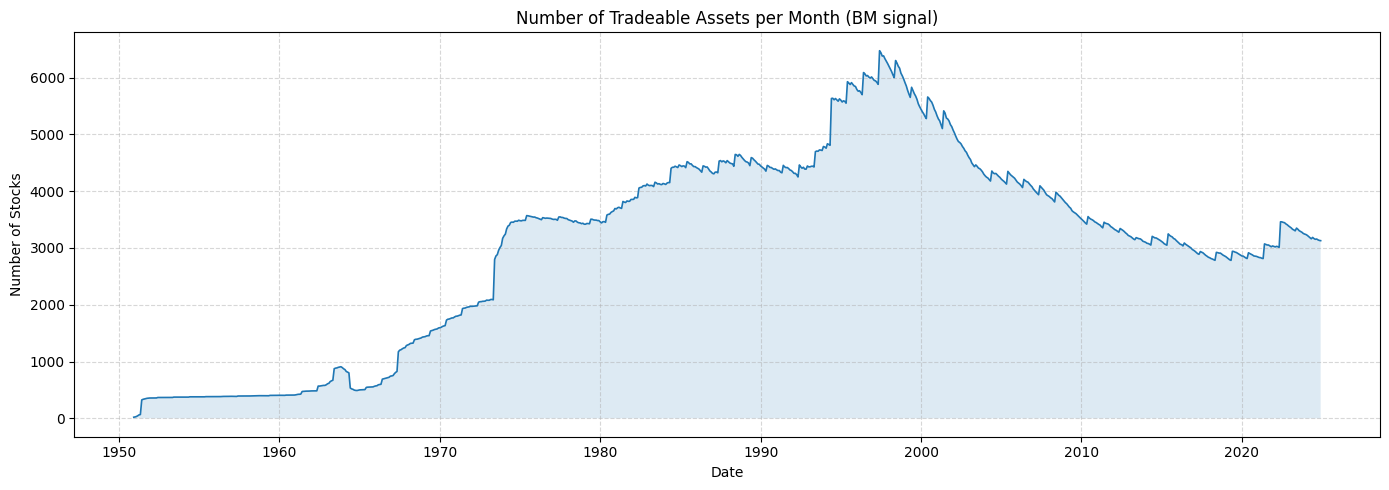

In [17]:

# Count non-null BM values per month (= tradeable shares)
tradeable = df.groupby('yyyymm')['BM'].count().reset_index()
tradeable.columns = ['yyyymm', 'n_tradeable']
tradeable['date'] = pd.to_datetime(tradeable['yyyymm'].astype(str), format='%Y%m')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tradeable['date'], tradeable['n_tradeable'], linewidth=1.2)
ax.fill_between(tradeable['date'], tradeable['n_tradeable'], alpha=0.15)
ax.set_title('Number of Tradeable Assets per Month (BM signal)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Stocks')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
